# PrediCT GSoC 2026 – Project 2 (Radiomics & Phenotyping)

This notebook presents my evaluation-task submission for PrediCT Project 2. I first built the required common COCA preprocessing pipeline, then completed the Project 2-specific radiomics workflow on a balanced 24-scan subset of the COCA dataset.

The final workflow includes:
- COCA DICOM/XML preprocessing into canonical NIfTI image-mask pairs
- resampling for radiomics compatibility
- Agatston scoring using original spacing
- PyRadiomics feature extraction
- statistical analysis using Spearman correlation and Kruskal–Wallis testing

The goal is to demonstrate a reproducible and project-aligned pipeline for radiomics feature extraction and calcium phenotyping.

## Task alignment

This submission is designed to match the PrediCT evaluation requirements.

### Common task
I implemented a COCA preprocessing workflow tailored for radiomics:
- DICOM/XML parsing
- canonical image/mask generation
- radiomics-compatible resampling
- structured scan indexing
- dataset statistics generation

### Project 2 task
For Project 2, I:
- extracted the requested PyRadiomics feature families
- computed Agatston scores using original spacing
- assigned the required Agatston categories: 0, 1–99, 100–399, and ≥400
- analysed associations between radiomics features and Agatston using Spearman correlation and Kruskal–Wallis testing

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS = ROOT / "data" / "results" / "project2_balanced_24"
ANALYSIS = RESULTS / "analysis"

agatston_csv = RESULTS / "agatston_scores.csv"
radiomics_csv = RESULTS / "radiomics_features.csv"
merged_csv = RESULTS / "project2_merged.csv"
spearman_csv = ANALYSIS / "spearman_correlations.csv"
kruskal_csv = ANALYSIS / "kruskal_wallis.csv"
subset_csv = ROOT / "data" / "manifests" / "project2_balanced_24.csv"

In [8]:
subset_df = pd.read_csv(subset_csv)
agatston_df = pd.read_csv(agatston_csv)
radiomics_df = pd.read_csv(radiomics_csv)
merged_df = pd.read_csv(merged_csv)
spearman_df = pd.read_csv(spearman_csv)
kruskal_df = pd.read_csv(kruskal_csv)

print("subset:", subset_df.shape)
print("agatston:", agatston_df.shape)
print("radiomics:", radiomics_df.shape)
print("merged:", merged_df.shape)


subset: (24, 15)
agatston: (24, 8)
radiomics: (24, 16)
merged: (24, 23)


## Dataset and preprocessing summary

The raw COCA dataset was provided as gated cardiac CT DICOM series with calcium XML annotations. I used the official PrediCT helper scripts as the starting point, then adapted the workflow to run locally on WSL/Linux.

### Preprocessing steps
1. Flatten nested gated DICOM folders so each patient folder directly contains `.dcm` slices.
2. Parse XML calcium annotations into 3D binary masks.
3. Convert each scan into canonical NIfTI image-mask pairs.
4. Build an index of processed scans.
5. Resample the canonical volumes to 0.7 × 0.7 × 3.0 mm for radiomics compatibility.

### Two-branch design
I intentionally kept two data branches:
- **Canonical/original-spacing branch** for Agatston scoring
- **Resampled branch** for PyRadiomics extraction

This separation is important because the evaluation task explicitly requires Agatston to use original spacing, while the common task requires resampling and Project 2 requires radiomics compatibility.

## Common-task justification

I designed the common COCA preprocessing pipeline to support radiomics analysis rather than segmentation training. The pipeline converts gated CT DICOM scans and XML calcium annotations into canonical image-mask NIfTI pairs, which makes downstream processing reproducible and easier to validate. I also preserved a canonical/original-spacing branch for Agatston scoring because the evaluation task explicitly requires Agatston computation in original spacing, and mixing that step with resampled data would risk changing the score.

For radiomics compatibility, I added a resampling branch at 0.7 × 0.7 × 3.0 mm so that extracted features are computed on a more standardized voxel grid. This improves consistency across scans and is more appropriate for texture and shape analysis. The resulting structure cleanly separates preprocessing concerns: original geometry is preserved for calcium scoring, while resampled images are used for feature extraction and phenotyping analysis.

## Project 2 methodology justification

I selected a balanced 24-case subset to ensure representation across all required Agatston categories (0, 1–99, 100–399, and ≥400). Agatston scores were computed from canonical image-mask pairs using original spacing, while PyRadiomics features were extracted from resampled image-mask pairs. I focused on the feature families explicitly requested in the task: shape, GLCM, GLSZM, and GLRLM, with additional calcium intensity and volume summaries. Statistical analysis was then performed using Spearman correlation to assess monotonic relationships with Agatston and Kruskal–Wallis testing to assess between-category separation.

## Processed dataset summary

The full preprocessing stage successfully generated canonical image-mask pairs and resampled image-mask pairs for the usable COCA scans. For the final Project 2 analysis, I used a balanced 24-case subset built from the usable processed scans.

### Balanced subset goal
- 6 cases from Agatston category 0
- 6 cases from Agatston category 1–99
- 6 cases from Agatston category 100–399
- 6 cases from Agatston category ≥400

This balanced design was chosen because an earlier unbalanced subset produced weak category coverage and reduced the usefulness of Kruskal–Wallis comparisons.

In [9]:
subset_df[["patient_id", "scan_id", "voxels", "num_slices"]]


,patient_id,scan_id,voxels,num_slices
0,268,5564e05bf7c0,0,0
1,451,088b1fc98638,0,0
2,452,6e03e5b69ea2,0,0
3,453,854f4aaed659,0,0
4,454,dc66db38089e,0,0
5,455,9b3cc19ee163,0,0
6,171,48d41c81106a,353,2
7,213,e6d667f90877,260,6
8,319,b4b5023db684,293,7
9,276,d8d0ca7f73c9,200,3


## Agatston scoring results

Agatston scoring was computed on the canonical/original-spacing branch. This preserves the geometric assumptions of the standard score and follows the evaluation requirement to use original spacing.

The balanced subset covers all four required Agatston categories:
- 0
- 1–99
- 100–399
- ≥400

This category coverage enables both continuous association analysis and grouped statistical comparisons.

,count
agatston_category,
0,6
1-99,6
100-399,6
>=400,6


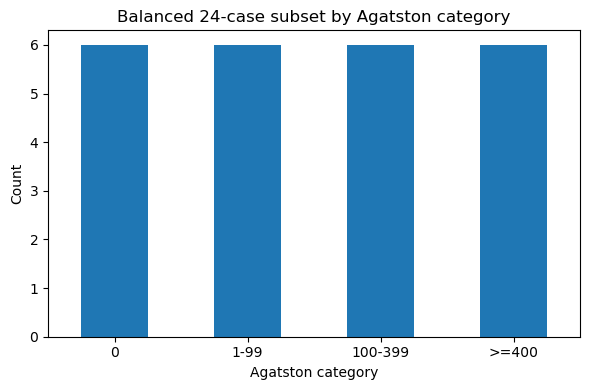

In [10]:
cat_counts = agatston_df["agatston_category"].value_counts().reindex(
    ["0", "1-99", "100-399", ">=400"]
)
display(cat_counts.to_frame("count"))

plt.figure(figsize=(6, 4))
cat_counts.plot(kind="bar")
plt.title("Balanced 24-case subset by Agatston category")
plt.xlabel("Agatston category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Radiomics feature extraction

Radiomics features were extracted from the resampled image-mask pairs using PyRadiomics. I focused on the feature families explicitly requested in the evaluation task:

- **Shape**: Sphericity, SurfaceVolumeRatio, Maximum3DDiameter
- **GLCM**: Contrast, Correlation, InverseDifferenceMoment
- **GLSZM**: SmallAreaEmphasis, LargeAreaEmphasis, ZonePercentage
- **GLRLM**: ShortRunEmphasis, LongRunEmphasis, RunPercentage

I also included:
- calcium mean HU
- calcium maximum HU
- calcium volume (mm³)

For zero-calcium cases, many shape and texture features are undefined because no positive calcium mask exists. In those cases, calcium volume remains defined as 0.0 while several other features are recorded as missing.

## Statistical association results

### Spearman correlation
The strongest continuous association with Agatston score was:
- **calcium_volume_mm3**: ρ ≈ 0.968, p ≈ 1.25e-14

Strong additional associations included:
- **shape_sphericity**: ρ ≈ -0.895, p ≈ 5.42e-07
- **shape_maximum_3d_diameter**: ρ ≈ 0.742, p ≈ 4.23e-04
- **shape_surface_volume_ratio**: ρ ≈ -0.721, p ≈ 7.28e-04
- **calcium_hu_max**: ρ ≈ 0.633, p ≈ 4.84e-03

### Kruskal–Wallis
The strongest between-category separation was:
- **calcium_volume_mm3**: H ≈ 21.94, p ≈ 6.70e-05

Additional significant or near-significant features included:
- **shape_sphericity**: p ≈ 5.11e-04
- **shape_maximum_3d_diameter**: p ≈ 1.89e-03
- **shape_surface_volume_ratio**: p ≈ 3.32e-03
- **calcium_hu_max**: p ≈ 1.12e-02
- **glszm_large_area_emphasis**: p ≈ 4.98e-02

In [11]:
display(spearman_df.head(10))
display(kruskal_df.head(10))

display(spearman_df[spearman_df["spearman_p"] < 0.05])
display(kruskal_df[kruskal_df["kruskal_p"] < 0.05])


,feature,spearman_rho,spearman_p,spearman_abs,n_non_null
0,calcium_volume_mm3,0.967543,1.248894e-14,0.967543,24
1,shape_sphericity,-0.894737,5.422111e-07,0.894737,18
2,shape_maximum_3d_diameter,0.742002,4.226652e-04,0.742002,18
3,shape_surface_volume_ratio,-0.721362,7.279599e-04,0.721362,18
4,calcium_hu_max,0.632611,4.841232e-03,0.632611,18
5,glcm_contrast,0.517028,2.800615e-02,0.517028,18
6,glszm_large_area_emphasis,0.500516,3.438378e-02,0.500516,18
7,glszm_zone_percentage,-0.453044,5.901671e-02,0.453044,18
8,calcium_hu_mean,0.453044,5.901671e-02,0.453044,18
9,glcm_correlation,0.411765,8.953915e-02,0.411765,18


,feature,kruskal_stat,kruskal_p,groups_used,n_non_null
0,calcium_volume_mm3,21.943463,0.000067,4,24
1,shape_sphericity,15.157895,0.000511,3,18
2,shape_maximum_3d_diameter,12.538012,0.001894,3,18
3,shape_surface_volume_ratio,11.415205,0.003321,3,18
4,calcium_hu_max,8.982456,0.011207,3,18
5,glszm_large_area_emphasis,6.000000,0.049787,3,18
6,glszm_zone_percentage,5.298246,0.070713,3,18
7,glcm_contrast,4.666667,0.096972,3,18
8,glcm_correlation,4.456140,0.107736,3,18
9,glszm_small_area_emphasis,4.257310,0.118997,3,18


,feature,spearman_rho,spearman_p,spearman_abs,n_non_null
0,calcium_volume_mm3,0.967543,1.248894e-14,0.967543,24
1,shape_sphericity,-0.894737,5.422111e-07,0.894737,18
2,shape_maximum_3d_diameter,0.742002,4.226652e-04,0.742002,18
3,shape_surface_volume_ratio,-0.721362,7.279599e-04,0.721362,18
4,calcium_hu_max,0.632611,4.841232e-03,0.632611,18
5,glcm_contrast,0.517028,2.800615e-02,0.517028,18
6,glszm_large_area_emphasis,0.500516,3.438378e-02,0.500516,18


,feature,kruskal_stat,kruskal_p,groups_used,n_non_null
0,calcium_volume_mm3,21.943463,0.000067,4,24
1,shape_sphericity,15.157895,0.000511,3,18
2,shape_maximum_3d_diameter,12.538012,0.001894,3,18
3,shape_surface_volume_ratio,11.415205,0.003321,3,18
4,calcium_hu_max,8.982456,0.011207,3,18
5,glszm_large_area_emphasis,6.000000,0.049787,3,18


Most radiomics features are undefined for zero-calcium cases because there is no positive lesion mask; therefore, some Kruskal–Wallis tests operate on three non-empty groups, while calcium volume remains defined across all four Agatston categories.

## Interpretation

The results are consistent with the expected behaviour of coronary calcium burden. Calcium volume shows the strongest relationship with Agatston score, which is reassuring because both are closely tied to calcified lesion extent. Shape features also appear informative: higher Agatston burden is associated with less compact and more spatially extensive lesions, reflected by strong effects in sphericity, maximum 3D diameter, and surface-volume ratio.

Texture and intensity features appear weaker than the strongest shape and volume descriptors, but some still show useful signal. In particular, calcium maximum HU and GLSZM large-area emphasis both contribute meaningful information, suggesting that both lesion density and coarse spatial aggregation matter for phenotyping.

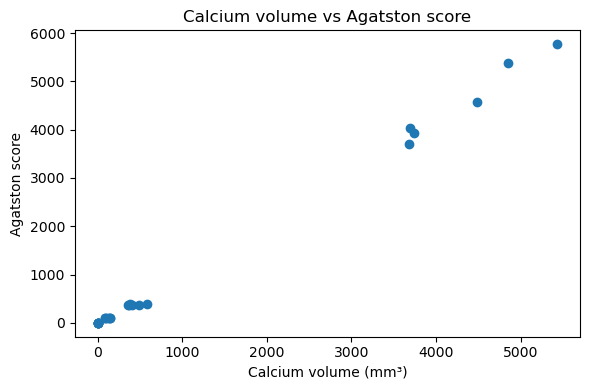

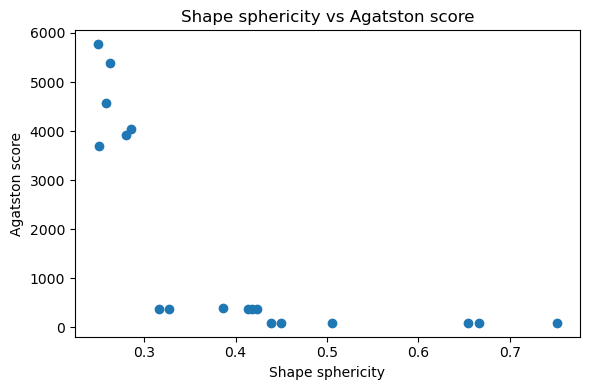

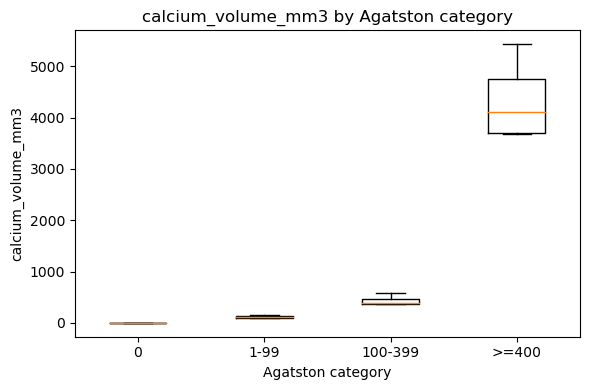

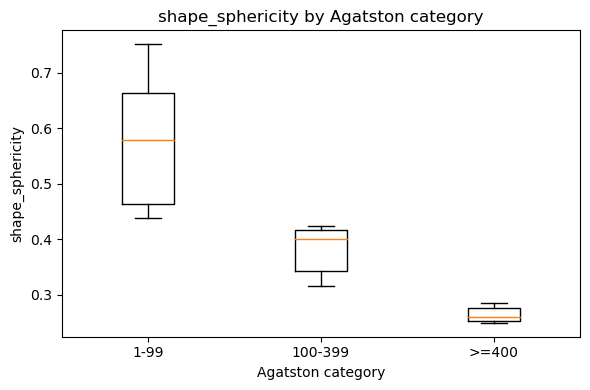

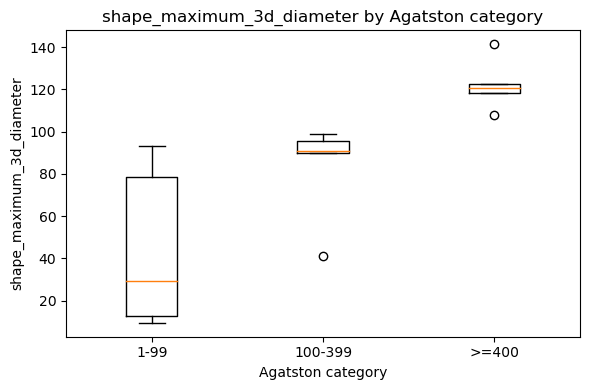

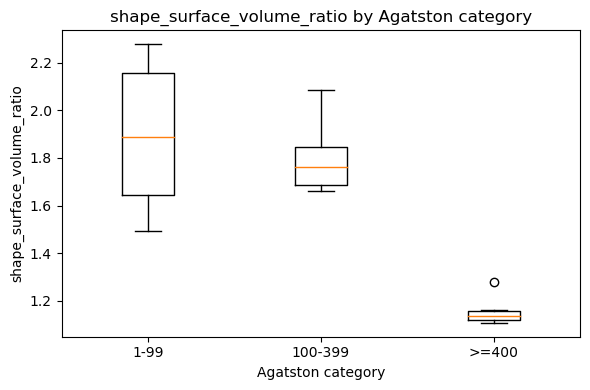

In [12]:
plt.figure(figsize=(6, 4))
plt.scatter(merged_df["calcium_volume_mm3"], merged_df["agatston_score"])
plt.xlabel("Calcium volume (mm³)")
plt.ylabel("Agatston score")
plt.title("Calcium volume vs Agatston score")
plt.tight_layout()
plt.show()

shape_df = merged_df.dropna(subset=["shape_sphericity", "agatston_score"])
plt.figure(figsize=(6, 4))
plt.scatter(shape_df["shape_sphericity"], shape_df["agatston_score"])
plt.xlabel("Shape sphericity")
plt.ylabel("Agatston score")
plt.title("Shape sphericity vs Agatston score")
plt.tight_layout()
plt.show()

features_to_plot = [
    "calcium_volume_mm3",
    "shape_sphericity",
    "shape_maximum_3d_diameter",
    "shape_surface_volume_ratio",
]

for feat in features_to_plot:
    sub = merged_df[["agatston_category", feat]].dropna()
    labels = [cat for cat in ["0", "1-99", "100-399", ">=400"] if (sub["agatston_category"] == cat).any()]
    groups = [sub.loc[sub["agatston_category"] == cat, feat].values for cat in labels]
    plt.figure(figsize=(6, 4))
    plt.boxplot(groups, labels=labels)
    plt.title(f"{feat} by Agatston category")
    plt.xlabel("Agatston category")
    plt.ylabel(feat)
    plt.tight_layout()
    plt.show()


## Limitations

This is an evaluation-task submission rather than a full clinical study, so the analysis is intentionally lightweight and scoped to the required task. The final balanced subset contains only 24 cases, which is enough to demonstrate the pipeline and reveal meaningful trends, but not enough to claim stable population-level phenotypes.

A second limitation is that zero-calcium cases naturally produce undefined values for many shape and texture features because there is no positive lesion mask. As a result, some radiomics variables are analysed across only three non-empty Agatston groups, whereas calcium volume remains defined across all four groups. In a full project, I would handle this more formally through zero-inflated feature logic, imputation policy design, or separate modelling for zero-calcium cases.

## Conclusion

This submission demonstrates a complete radiomics-oriented COCA preprocessing and analysis workflow aligned with PrediCT Project 2. I implemented canonical image-mask generation, radiomics-compatible resampling, Agatston scoring on original spacing, PyRadiomics extraction, and statistical association analysis. The final balanced subset shows that calcium volume and several shape descriptors are strongly associated with Agatston burden, supporting the feasibility of using radiomics for calcium phenotyping.

The next natural extensions would be:
1. expanding the analysis beyond 24 cases,
2. adding dimensionality reduction and clustering,
3. testing feature robustness under small perturbations,
4. identifying phenotype-defining features with a simple interpretable model.